# Aqui implementarei o algoritmo K-Nearest Neighbors para classificação binária do dataset MNIST - Hand digits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# importando a biblioteca com varios datasets nativos e prontos para análise
from sklearn.datasets import fetch_openml
np.random.seed(42)

In [3]:
# Carregando os dados
mnist = fetch_openml('mnist_784')

In [4]:
# O arquivo vem em forma de dicionário, para pegar os dados que queremos:
x, y = mnist['data'], mnist['target']

In [5]:
# Temos um dataset com 70 mil imagens,
# onde cada uma possui tamanho 28x28 pixels em apenas 1 CH, preto e branco.
print(x.shape) 
print(y.shape)

(70000, 784)
(70000,)


# Separando os dados
60mil imagens são de treinamento, enquanto as outras 10mil são para teste.
dessas 60 mil, vamos tirar 5 mil para validação e deixar as 10 mil para teste.

In [6]:
xtr, xte, xval, ytr, yte, yval = x[:55000,:], x[60000:,:], x[55000:60000], y[:55000], y[60000:], y[55000:60000]

In [7]:
print(xtr.shape)
print(xte.shape)
print(xval.shape)
print(ytr.shape)
print(yte.shape)
print(yval.shape)

(55000, 784)
(10000, 784)
(5000, 784)
(55000,)
(10000,)
(5000,)


# Classificador binário
O dataset MNIST é originalmente multiclasse, ou seja, são 10 classes. Para adaptar esse exercício ao meu mestrado, vou usar para classificar se um digito é w ou não, vamos escolher um digito qualquer:

In [8]:
np.count_nonzero(xtr == 2)

30781

In [9]:
# Então, vamos transformar em trues e falses, ou seja, 3 ou não 3:
ytr = (ytr == '2')
yte = (yte == '2')
yval = (yval == '2')

In [10]:
True in ytr

True

# Treinando o modelo
Agora vamos treinar nosso KNN:

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
knn = KNeighborsClassifier(n_neighbors=1)

In [13]:
knn.fit(xtr, ytr)

KNeighborsClassifier(n_neighbors=1)

# Medindo a Performance
Agora vamos medir a performance de diferentes formas, considerando que é um sistema de classificação binária em que as classes não estão balanceadas. Ou seja, temos 10% das features como True e 90% como False. Precisamos levar isso em conta na hora e escolher o medidor de performance

In [14]:
pred1 = knn.predict(xval)

In [15]:
# Confusion Matrix e Classification Report
from sklearn.metrics import confusion_matrix as cm, classification_report as cr

In [16]:
print('Confusion Matrix :')
print(cm(yval, pred1))
print('\n')
print('Classification Report')
print(cr(yval, pred1))

Confusion Matrix :
[[4501    6]
 [   8  485]]


Classification Report
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      4507
        True       0.99      0.98      0.99       493

    accuracy                           1.00      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       1.00      1.00      1.00      5000



# Escolhendo o melhor K

In [17]:
error_rate = []

# Will take some time
import time
from datetime import timedelta
start_time = time.monotonic()

for i in range(1,20):
    print('loop %s'%i)
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtr,ytr)
    pred_i = knn.predict(xval)
    error_rate.append(np.mean(pred_i != yval))

end_time = time.monotonic()
print(timedelta(seconds=end_time - start_time))

loop 1
loop 2
loop 3
loop 4
loop 5
loop 6
loop 7
loop 8
loop 9
loop 10
loop 11
loop 12
loop 13
loop 14
loop 15
loop 16
loop 17
loop 18
loop 19
3:30:17.265000


Text(0, 0.5, 'Error Rate')

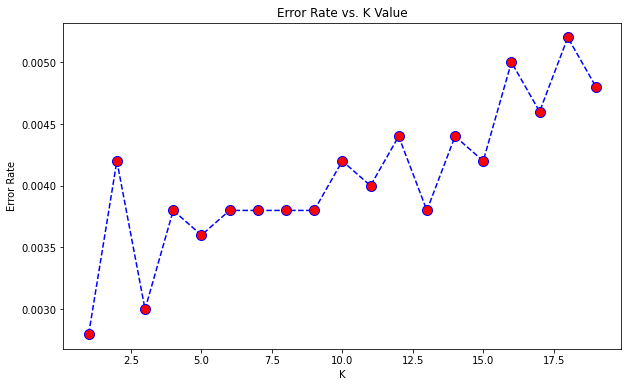

In [18]:
plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [19]:
bestK = min(error_rate)

In [21]:
BestKNN = KNeighborsClassifier(n_neighbors=1)
BestKNN.fit(xtr, ytr)
Bestpred = BestKNN.predict(xte)

In [23]:
print('Confusion Matrix :')
print(cm(yte, Bestpred))
print('\n')
print('Classification Report')
print(cr(yte, Bestpred))

Confusion Matrix :
[[8951   17]
 [  38  994]]


Classification Report
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      8968
        True       0.98      0.96      0.97      1032

    accuracy                           0.99     10000
   macro avg       0.99      0.98      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [24]:
import joblib

In [26]:
nome_arquivo = 'knn_mnist.sav'

In [27]:
joblib.dump(BestKNN, nome_arquivo)

['knn_mnist.sav']

In [30]:
loaded_model = joblib.load('knn_mnist.sav')
result = loaded_model.score(xval, yval)
print(result)

0.9972
